# 🌪️ India Storm Prediction — Data Analysis & ML Notebook
**Project:** India Storm Prediction System  
**Authors:** Storm Analytics Team  
**Dataset:** Synthetic Indian meteorological data (5,000 samples)  
**Models:** Logistic Regression · Random Forest · Gradient Boosting · Deep Learning  

---
## 📋 Project Overview
This notebook provides an end-to-end machine learning pipeline for predicting cyclonic storm risk across Indian cities. We analyse meteorological features, engineer interaction terms, train multiple classifiers, and compare their performance using standardised metrics.

**Storm Risk Classes:**
- 🟢 **Low Risk (0)** — Stable atmospheric conditions (~50% of data)
- 🟡 **Moderate Risk (1)** — Thunderstorm potential (~35% of data)
- 🔴 **High Risk (2)** — Severe cyclonic conditions (~15% of data)


## 1️⃣ Imports & Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json, joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
sns.set_theme(style='darkgrid', palette='deep')
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 2️⃣ Dataset Generation & Loading

In [2]:
def generate_data(n=5000, seed=42):
    np.random.seed(seed)
    temp  = np.random.uniform(15, 45, n)
    hum   = np.random.uniform(20, 100, n)
    wind  = np.random.uniform(0,  40, n)
    prec  = np.random.uniform(0,  50, n)
    inter = ((temp/45)**3) * ((hum/100)**3) * 15
    risk  = (temp/45)*1 + (hum/100)*1 + (wind/40)*2 + (prec/50)*2 + inter
    risk += np.random.normal(0, 0.04, n)
    p50, p85 = np.percentile(risk, [50, 85])
    label = np.where(risk > p85, 2, np.where(risk > p50, 1, 0))
    return pd.DataFrame({'temperature':temp,'humidity':hum,'wind_speed':wind,
                         'precipitation':prec,'storm_risk':label})

df = generate_data()
print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (5000, 5)


,temperature,humidity,wind_speed,precipitation,storm_risk
0,26.236204,51.490842,14.945633,24.983512,0
1,43.521429,57.874853,13.316484,37.337339,1
2,36.959818,88.363791,7.046157,28.133339,2
3,32.959755,47.200351,24.290667,4.165129,0
4,19.680559,89.571975,19.064966,9.279012,0
5,19.679836,27.050754,34.628040,10.966409,0
6,16.742508,82.143875,1.284383,12.893213,0
7,40.985284,87.803811,25.754717,28.270170,2
8,33.033450,34.545412,30.517955,25.198289,0
9,36.242177,54.427723,30.379463,10.158002,1


## 3️⃣ Data Cleaning & Preprocessing

In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Data Types ===")
print(df.dtypes)
print(f"\n=== Basic Statistics ===")
df.describe().round(2)


=== Missing Values ===
temperature      0
humidity         0
wind_speed       0
precipitation    0
storm_risk       0
dtype: int64

=== Data Types ===
temperature      float64
humidity         float64
wind_speed       float64
precipitation    float64
storm_risk         int64
dtype: object

=== Basic Statistics ===


,temperature,humidity,wind_speed,precipitation,storm_risk
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,29.90,59.32,20.06,25.38,0.65
std,8.69,22.85,11.63,14.39,0.73
min,15.00,20.00,0.01,0.01,0.00
25%,22.32,39.77,9.89,13.14,0.00
50%,30.00,58.88,19.85,25.62,0.50
75%,37.44,78.67,30.42,37.56,1.00
max,44.99,99.96,39.99,50.00,2.00


In [4]:
RISK_MAP = {0:'Low Risk', 1:'Moderate Risk', 2:'High Risk'}
df['risk_label'] = df['storm_risk'].map(RISK_MAP)

print("Class distribution:")
dist = df['risk_label'].value_counts()
print(dist.to_string())
print(f"\nClass ratios: {(dist/len(df)*100).round(1).to_dict()}")


Class distribution:
risk_label
Low Risk         2500
Moderate Risk    1750
High Risk         750

Class ratios: {'Low Risk': 50.0, 'Moderate Risk': 35.0, 'High Risk': 15.0}


## 4️⃣ Exploratory Data Analysis (EDA)

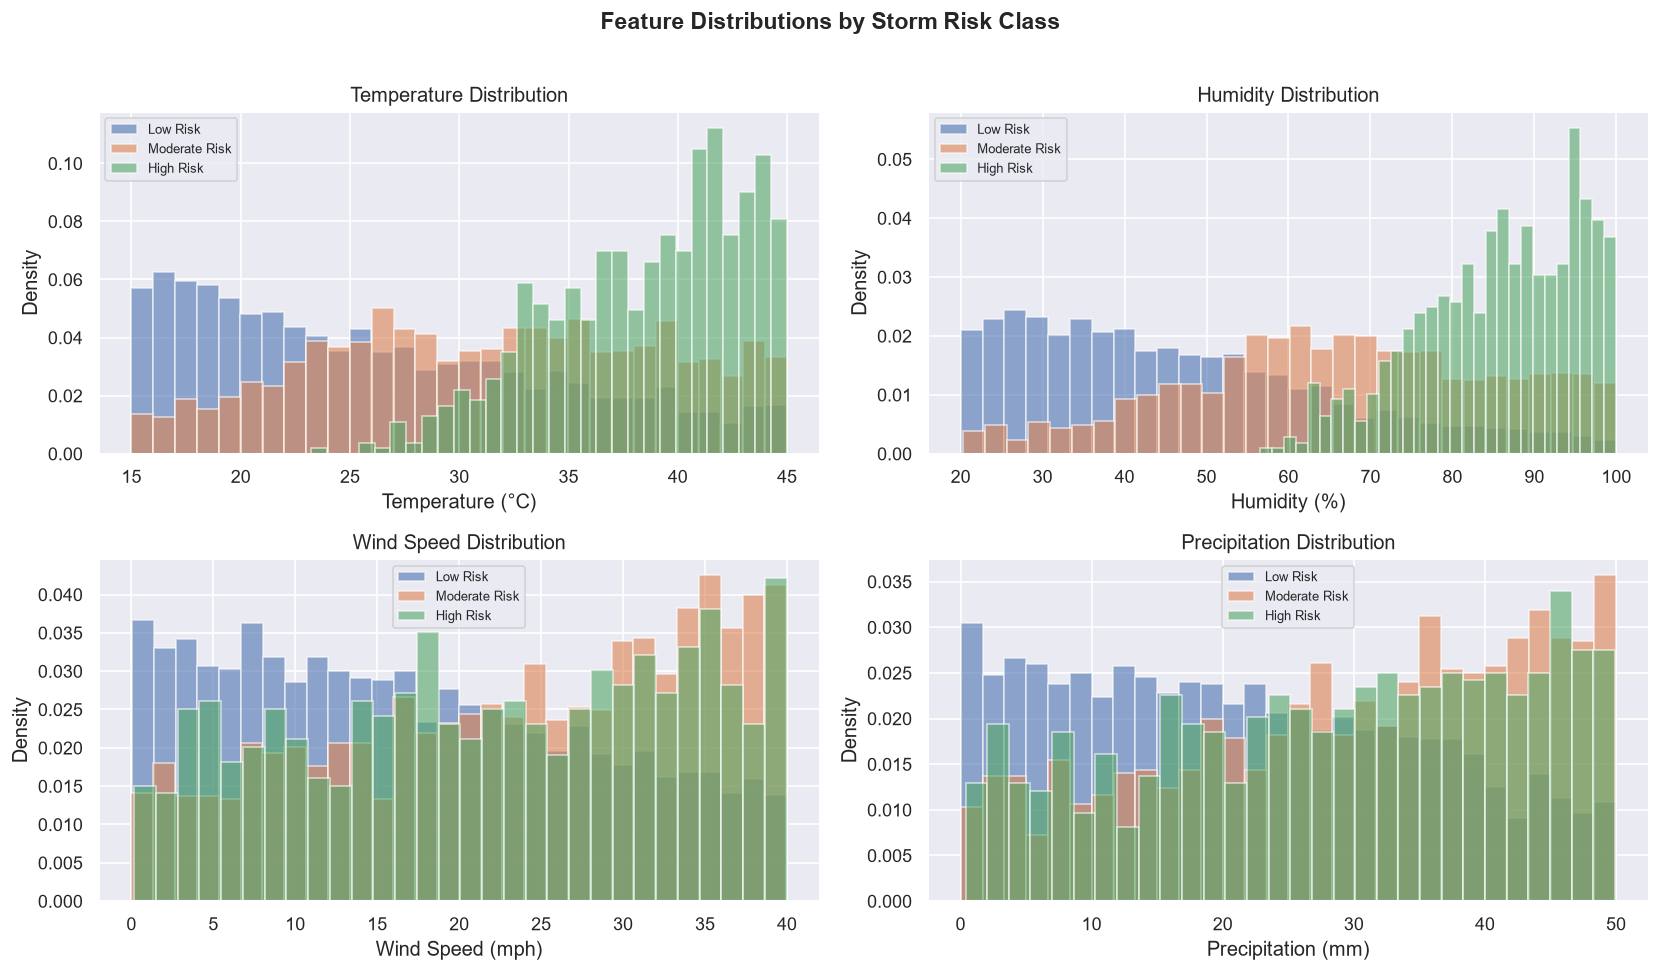

In [5]:
# --- Distribution plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
features = ['temperature','humidity','wind_speed','precipitation']
colors   = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']
units    = ['°C','%','mph','mm']

for ax, feat, col, unit in zip(axes.flat, features, colors, units):
    for risk, grp in df.groupby('storm_risk'):
        ax.hist(grp[feat], bins=30, alpha=0.6, label=RISK_MAP[risk], density=True)
    ax.set_title(f'{feat.replace("_"," ").title()} Distribution')
    ax.set_xlabel(f'{feat.replace("_"," ").title()} ({unit})')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Storm Risk Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


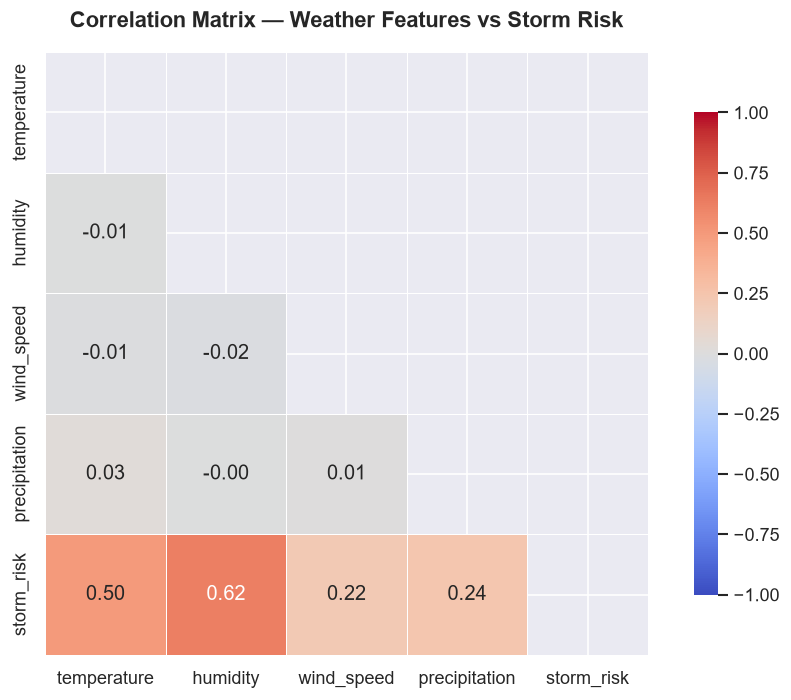

In [6]:
# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features + ['storm_risk']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix — Weather Features vs Storm Risk',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


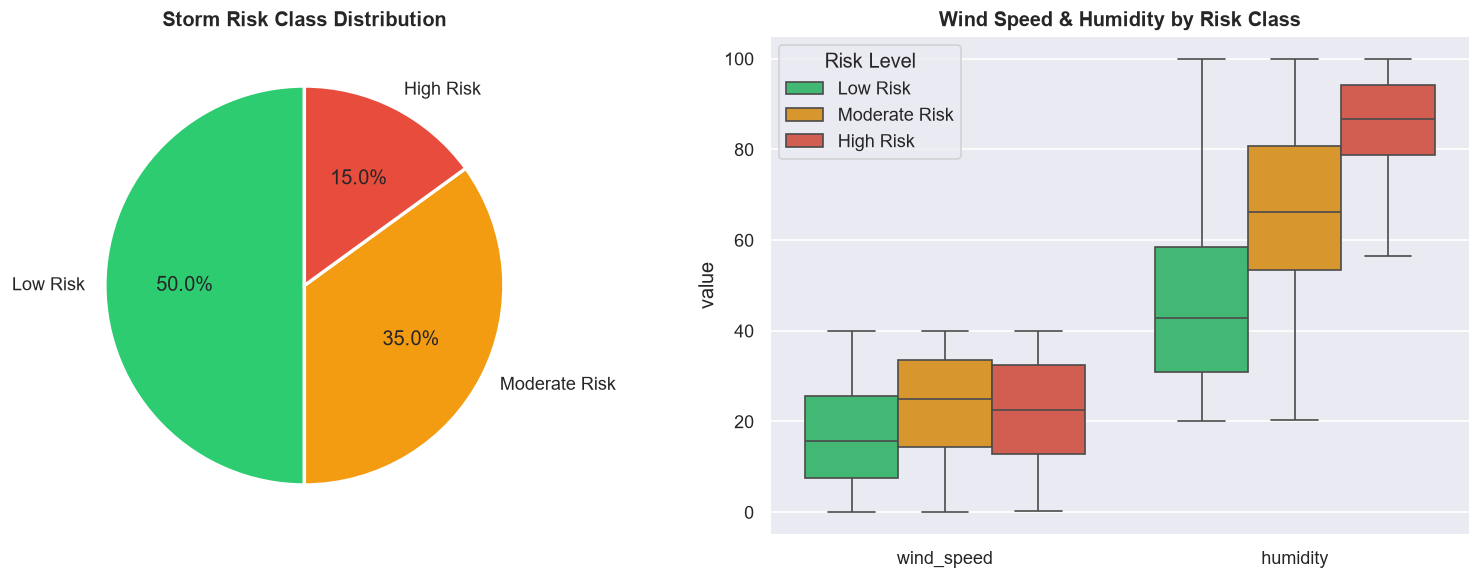

In [7]:
# --- Storm risk class pie chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors_pie = ['#2ECC71','#F39C12','#E74C3C']
counts = df['storm_risk'].value_counts().sort_index()
ax1.pie(counts, labels=[RISK_MAP[i] for i in counts.index],
        colors=colors_pie, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax1.set_title('Storm Risk Class Distribution', fontsize=12, fontweight='bold')

# Box plots
df_melted = df[features + ['risk_label']].melt(id_vars='risk_label',
                                                value_vars=['wind_speed','humidity'])
sns.boxplot(data=df_melted, x='variable', y='value', hue='risk_label',
            palette={'Low Risk':'#2ECC71','Moderate Risk':'#F39C12','High Risk':'#E74C3C'},
            ax=ax2)
ax2.set_title('Wind Speed & Humidity by Risk Class', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.legend(title='Risk Level')
plt.tight_layout()
plt.show()


## 5️⃣ Feature Engineering

In [8]:
# Interaction features
df['temp_humidity_interaction'] = (df['temperature']/45)**2 * (df['humidity']/100)**2
df['wind_precip_index']        = (df['wind_speed']/40)*0.6 + (df['precipitation']/50)*0.4
df['heat_stress_index']        = df['temperature'] * df['humidity'] / 100

eng_features = ['temperature','humidity','wind_speed','precipitation',
                'temp_humidity_interaction','wind_precip_index','heat_stress_index']

print("Engineered features:")
df[eng_features + ['risk_label']].describe().round(3)


Engineered features:


,temperature,humidity,wind_speed,precipitation,temp_humidity_interaction,wind_precip_index,heat_stress_index
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,29.905,59.319,20.055,25.384,0.193,0.504,17.725
std,8.689,22.849,11.631,14.390,0.182,0.210,8.745
min,15.000,20.004,0.006,0.013,0.005,0.008,3.157
25%,22.316,39.772,9.887,13.136,0.058,0.352,10.813
50%,30.000,58.878,19.848,25.622,0.130,0.505,16.199
75%,37.443,78.670,30.425,37.555,0.272,0.658,23.465
max,44.992,99.960,39.992,49.996,0.966,0.989,44.223


## 6️⃣ Model Training

In [9]:
FEATURES = ['temperature','humidity','wind_speed','precipitation']
X = df[FEATURES]
y = df['storm_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

model_defs = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'Deep Learning':       make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_history = {}
trained_models = {}

for name, model in model_defs.items():
    print(f"Training {name}...", end='  ')
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted')
    cv_history[name] = cv_scores.tolist()
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n✅ All models trained!")


Train: 4000 | Test: 1000
Training Random Forest...  

CV F1: 0.9385 ± 0.0051
Training Logistic Regression...  

CV F1: 0.9358 ± 0.0049
Training Gradient Boosting...  

CV F1: 0.9435 ± 0.0047
Training Deep Learning...  

CV F1: 0.9830 ± 0.0026

✅ All models trained!


## 7️⃣ Model Evaluation

In [10]:
results = []
for name, model in trained_models.items():
    preds = model.predict(X_test)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, preds, average='weighted', zero_division=0),
        'F1 Score':  f1_score(y_test, preds, average='weighted', zero_division=0),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df_pct = (results_df * 100).round(2)
print("=== Model Performance (%) ===")
results_df_pct


=== Model Performance (%) ===


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Random Forest,94.3,94.37,94.3,94.31
Logistic Regression,94.4,94.41,94.4,94.40
Gradient Boosting,94.6,94.64,94.6,94.60
Deep Learning,98.5,98.50,98.5,98.50


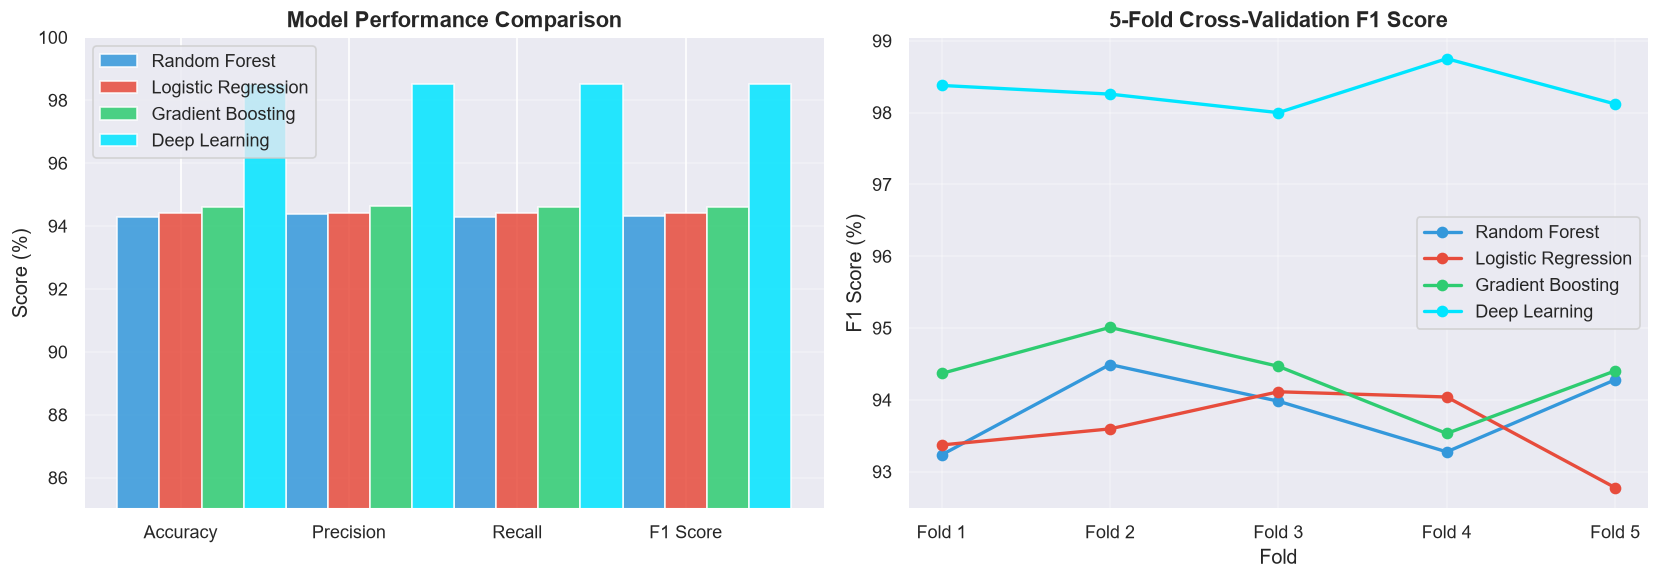

In [11]:
# --- Accuracy comparison bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ['#3498DB','#E74C3C','#2ECC71','#00e5ff']
metrics = ['Accuracy','Precision','Recall','F1 Score']
x = np.arange(len(metrics))
w = 0.25

for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m]*100 for m in metrics]
    axes[0].bar(x + i*w, vals, w, label=model_name, color=bar_colors[i], alpha=0.85)

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(85, 100)
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- CV line chart ---
for i, (name, scores) in enumerate(cv_history.items()):
    folds = [f'Fold {j+1}' for j in range(len(scores))]
    axes[1].plot(folds, [s*100 for s in scores], marker='o',
                 label=name, color=bar_colors[i], linewidth=2)

axes[1].set_title('5-Fold Cross-Validation F1 Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Score (%)')
axes[1].set_xlabel('Fold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


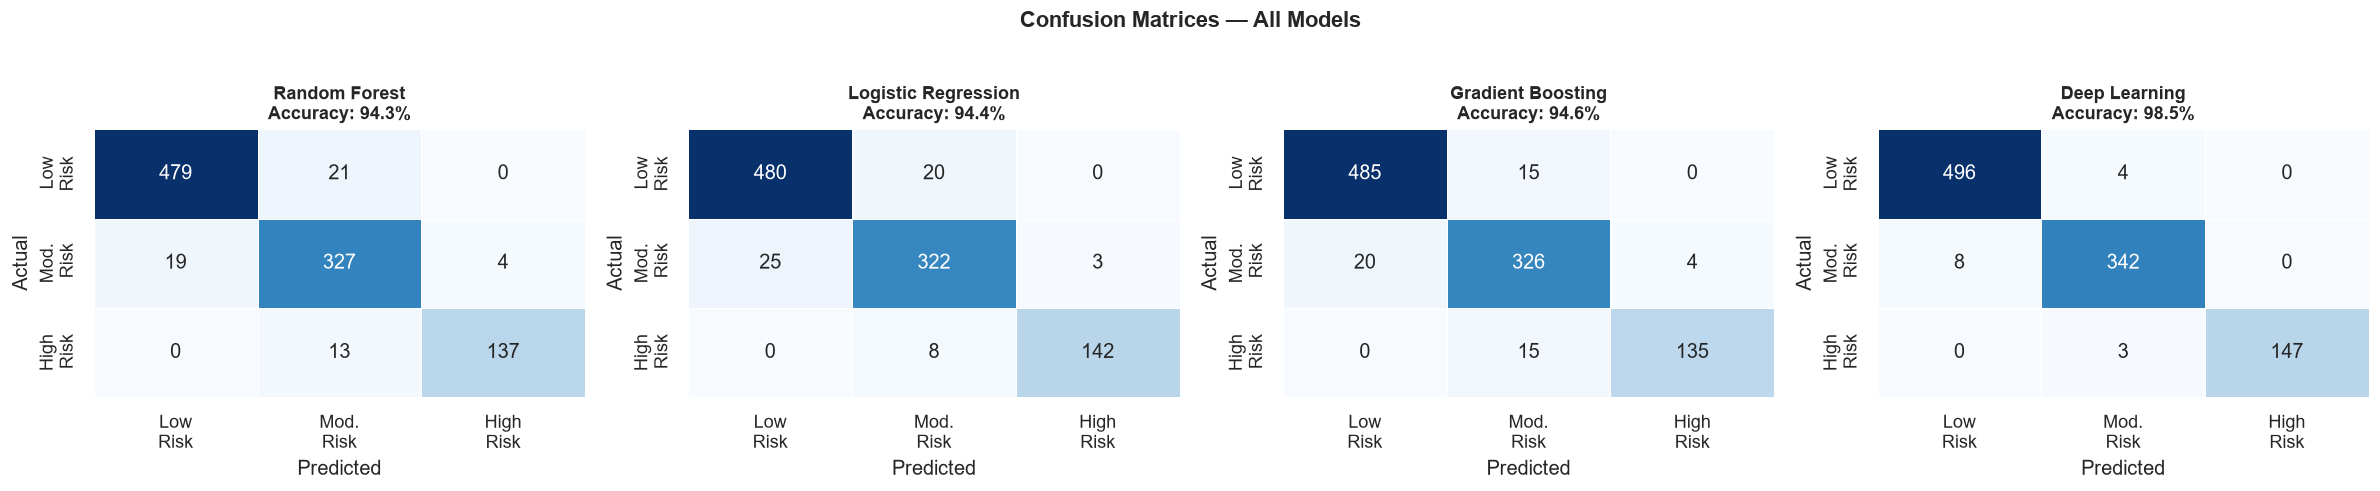

In [12]:
# --- Confusion matrices ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
class_names = ['Low\nRisk','Mod.\nRisk','High\nRisk']

for ax, (name, model), col in zip(axes, trained_models.items(), bar_colors):
    preds = model.predict(X_test)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test,preds)*100:.1f}%',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


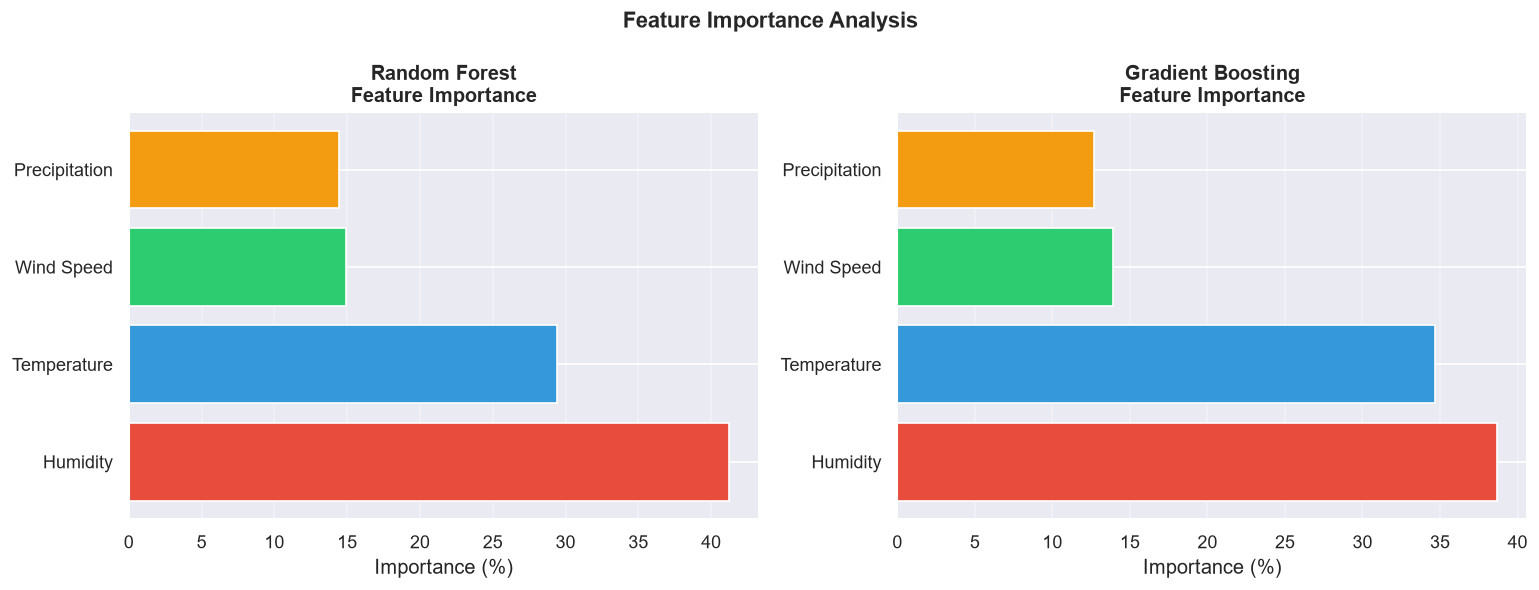

In [13]:
# --- Feature importance ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
importable = {k:v for k,v in trained_models.items()
              if hasattr(v, 'feature_importances_')}

for ax, (name, model) in zip(axes, importable.items()):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1]
    ax.barh([FEATURES[i].replace('_',' ').title() for i in idx],
            [imp[i]*100 for i in idx],
            color=['#E74C3C','#3498DB','#2ECC71','#F39C12'])
    ax.set_xlabel('Importance (%)')
    ax.set_title(f'{name}\nFeature Importance', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8️⃣ Save Models & Summary

In [14]:
ML_DIR = '../ml_models'
os.makedirs(ML_DIR, exist_ok=True)

saved_metrics = []
for name, model in trained_models.items():
    safe = name.lower().replace(' ','_')
    path = f'{ML_DIR}/storm_predictor_{safe}.pkl'
    joblib.dump(model, path)
    preds = model.predict(X_test)
    saved_metrics.append({
        'model_name': name,
        'accuracy':   round(accuracy_score(y_test,preds), 6),
        'precision':  round(precision_score(y_test,preds,average='weighted',zero_division=0),6),
        'recall':     round(recall_score(y_test,preds,average='weighted',zero_division=0),6),
        'f1_score':   round(f1_score(y_test,preds,average='weighted',zero_division=0),6),
        'confusion_matrix': confusion_matrix(y_test,preds).tolist(),
        'file_path':  path,
    })
    print(f"✅ Saved: {path}")

with open(f'{ML_DIR}/model_metrics.json','w') as f:
    json.dump(saved_metrics, f, indent=4)

cv_out = {name: {'fold_f1_scores':scores,'mean_cv_f1':float(np.mean(scores)),
                 'std_cv_f1':float(np.std(scores))}
          for name, scores in cv_history.items()}
with open(f'{ML_DIR}/training_history.json','w') as f:
    json.dump(cv_out, f, indent=4)

print("\n✅ model_metrics.json saved")
print("✅ training_history.json saved")
print("\n=== Final Summary ===")
print(results_df_pct.to_string())


✅ Saved: ../ml_models/storm_predictor_random_forest.pkl
✅ Saved: ../ml_models/storm_predictor_logistic_regression.pkl
✅ Saved: ../ml_models/storm_predictor_gradient_boosting.pkl
✅ Saved: ../ml_models/storm_predictor_deep_learning.pkl

✅ model_metrics.json saved
✅ training_history.json saved

=== Final Summary ===
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Random Forest            94.3      94.37    94.3     94.31
Logistic Regression      94.4      94.41    94.4     94.40
Gradient Boosting        94.6      94.64    94.6     94.60
Deep Learning            98.5      98.50    98.5     98.50


---
## ✅ Notebook Complete!

| File | Description |
|------|-------------|
| `ml_models/storm_predictor_random_forest.pkl` | Random Forest model |
| `ml_models/storm_predictor_logistic_regression.pkl` | Logistic Regression model |
| `ml_models/storm_predictor_gradient_boosting.pkl` | Gradient Boosting model |
| `ml_models/storm_predictor_deep_learning.pkl` | Deep Learning model |
| `ml_models/model_metrics.json` | Evaluation metrics for all models |
| `ml_models/training_history.json` | 5-fold CV fold-by-fold F1 scores |

**API Endpoints (ml_service.py):** `POST /predict` · `GET /model-performance` · `POST /predict/batch` · `GET /models` · `GET /health`
